In [1]:
!pip install -q diffusers transformers accelerate lpips torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.4 MB/s eta 0:00:00


In [2]:
!find /kaggle/working -mindepth 1 -maxdepth 1 ! -name 'data' -exec rm -rf {} +

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from diffusers import DDPMPipeline, DDPMScheduler
import lpips
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(101)
random.seed(101)
np.random.seed(101)

Using device: cuda


In [5]:
ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
unet = ddpm_pipe.unet
scheduler: DDPMScheduler = ddpm_pipe.scheduler
scheduler.set_timesteps(1000)  # full schedule; we'll only use a slice of it


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [6]:
# DDPM was trained on images scaled to [-1, 1]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

CLASSES = train_set.classes  # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_indices_by_class(dataset, class_idx):
    return [i for i, (_, y) in enumerate(dataset) if y == class_idx]


In [7]:
class SurrogateResNet(nn.Module):
    """Small ResNet-ish CNN, fast to train on CIFAR-10 from scratch."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # -> 256-d feature vector
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, return_features=False):
        feat = self.features(x).flatten(1)
        out = self.classifier(feat)
        if return_features:
            return out, feat
        return out


def train_surrogate(epochs=10, batch_size=128):
    model = SurrogateResNet().to(device)
    loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Surrogate] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model

surrogate = train_surrogate(epochs=15)  # ~2-3 min on a T4


[Surrogate] epoch 1/15 loss=1.2420 acc=0.5511
[Surrogate] epoch 2/15 loss=0.8499 acc=0.7005
[Surrogate] epoch 3/15 loss=0.6843 acc=0.7608
[Surrogate] epoch 4/15 loss=0.5817 acc=0.8004
[Surrogate] epoch 5/15 loss=0.4955 acc=0.8289
[Surrogate] epoch 6/15 loss=0.4297 acc=0.8522
[Surrogate] epoch 7/15 loss=0.3784 acc=0.8690
[Surrogate] epoch 8/15 loss=0.3279 acc=0.8897
[Surrogate] epoch 9/15 loss=0.2857 acc=0.9011
[Surrogate] epoch 10/15 loss=0.2443 acc=0.9166
[Surrogate] epoch 11/15 loss=0.2049 acc=0.9296
[Surrogate] epoch 12/15 loss=0.1781 acc=0.9387
[Surrogate] epoch 13/15 loss=0.1482 acc=0.9495
[Surrogate] epoch 14/15 loss=0.1225 acc=0.9590
[Surrogate] epoch 15/15 loss=0.1053 acc=0.9650


In [8]:
lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters():
    p.requires_grad_(False)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 202MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [9]:
def make_poison(
    base_img: torch.Tensor,       # [1,3,32,32] in [-1,1], true label = class A (stays clean-label)
    target_img: torch.Tensor,     # [1,3,32,32] in [-1,1], the test-time image we want misclassified
    surrogate_model: nn.Module,
    t_start: int = 100,           # how far to forward-diffuse (out of 1000). Lower = closer to original.
    guidance_scale: float = 20.0, # strength of feature-collision pull
    lpips_weight: float = 0.15,   # how much to penalize perceptual drift from base_img
    num_inference_steps: int = 50,
):
    """
    Returns a poisoned image that:
      - still visually/semantically belongs to base_img's true class (clean-label constraint)
      - has surrogate CNN features close to target_img's features (feature collision)
    """
    base_img = base_img.to(device)
    target_img = target_img.to(device)

    with torch.no_grad():
        _, target_feat = surrogate_model(target_img, return_features=True)

    # --- Step 1: partial forward diffusion (SDEdit) ---
    scheduler.set_timesteps(num_inference_steps)
    timesteps = scheduler.timesteps  # descending, e.g. [980, 960, ..., 0]

    # find the timestep index closest to t_start
    start_idx = (timesteps - t_start).abs().argmin().item()
    t0 = timesteps[start_idx]

    noise = torch.randn_like(base_img)
    x_t = scheduler.add_noise(base_img, noise, t0.unsqueeze(0))

    # --- Step 2: guided reverse diffusion ---
    # Only iterate over timesteps <= t0 (i.e. from start_idx to the end)
    active_timesteps = timesteps[start_idx:]

    x_t = x_t.detach().clone().requires_grad_(True)

    for t in active_timesteps:
        t_batch = t.unsqueeze(0).to(device)

        # predict noise (no grad needed through UNet weights, but we DO need
        # grad w.r.t. x_t, so keep it attached)
        noise_pred = unet(x_t, t_batch).sample

        # scheduler step gives us x_{t-1} AND the model's estimate of x0
        step_out = scheduler.step(noise_pred, t.item(), x_t)
        x_prev = step_out.prev_sample
        pred_x0 = step_out.pred_original_sample  # estimate of clean image at this step

        # --- guidance loss on the predicted clean image ---
        pred_x0_clamped = pred_x0.clamp(-1, 1)
        _, feat = surrogate_model(pred_x0_clamped, return_features=True)

        feature_collision_loss = F.mse_loss(feat, target_feat.detach())
        perceptual_loss = lpips_fn(pred_x0_clamped, base_img).mean()

        total_loss = feature_collision_loss - lpips_weight * (-perceptual_loss)
        # (we ADD lpips as a penalty, written this way to make sign explicit)
        total_loss = feature_collision_loss + lpips_weight * perceptual_loss

        grad = torch.autograd.grad(total_loss, x_t, retain_graph=False)[0]

        # nudge x_prev opposite the gradient direction (minimize loss),
        # scaled by guidance_scale and current noise level
        with torch.no_grad():
            x_prev = x_prev - guidance_scale * (t.item() / 1000.0) * grad

        x_t = x_prev.detach().clone().requires_grad_(True)

    poison_img = x_t.detach().clamp(-1, 1)
    return poison_img


In [10]:
# # ============================================================
# # PATCH to Cell 8 — also return the original (unpoisoned) base images
# # ============================================================
# def generate_poison_set(
#     base_class_idx: int,
#     target_class_idx: int,
#     num_poisons: int = 25,
#     t_start: int = 250,
# ):
#     base_indices = get_indices_by_class(train_set, base_class_idx)
#     target_indices = get_indices_by_class(test_set, target_class_idx)

#     chosen_base = random.sample(base_indices, num_poisons)
#     target_idx = random.choice(target_indices)
#     target_img, _ = test_set[target_idx]
#     target_img = target_img.unsqueeze(0)

#     poisons = []
#     originals = []  # <-- NEW: keep the clean base images for comparison
#     for i, idx in enumerate(chosen_base):
#         base_img, base_label = train_set[idx]
#         base_img_batched = base_img.unsqueeze(0)
#         poison = make_poison(base_img_batched, target_img, surrogate, t_start=t_start)
#         poisons.append((poison.cpu(), base_label))
#         originals.append(base_img.cpu())  # <-- NEW
#         print(f"generated poison {i+1}/{num_poisons}")

#     return poisons, originals, target_img, target_idx


# # Re-run generation with the patched function
# poisons, originals, target_img, target_idx = generate_poison_set(
#     base_class_idx=CLASSES.index("cat"),
#     target_class_idx=CLASSES.index("dog"),
#     num_poisons=25,
#     t_start=250,
# )

In [11]:
# # ============================================================
# # CELL 8c — SSIM between each poison and its original clean image
# # ============================================================
# from skimage.metrics import structural_similarity as ssim
# import numpy as np
# import matplotlib.pyplot as plt

# def denorm(img):
#     """[-1,1] -> [0,1] for plotting"""
#     return (img.clamp(-1, 1) + 1) / 2

# def to_numpy_img(img_tensor):
#     """[1,3,32,32] or [3,32,32] in [-1,1] -> HWC float [0,1] numpy array"""
#     if img_tensor.dim() == 4:
#         img_tensor = img_tensor[0]
#     img = denorm(img_tensor).permute(1, 2, 0).cpu().numpy()
#     return np.clip(img, 0, 1)

# def compute_ssim_scores(poisons, originals):
#     scores = []
#     for (poison_img, label), orig_img in zip(poisons, originals):
#         p_np = to_numpy_img(poison_img)
#         o_np = to_numpy_img(orig_img)
#         score = ssim(o_np, p_np, channel_axis=2, data_range=1.0)
#         scores.append(score)
#     return scores

# ssim_scores = compute_ssim_scores(poisons, originals)

# print("=== SSIM (poison vs. original) ===")
# for i, s in enumerate(ssim_scores):
#     print(f"poison {i+1:2d}  label={CLASSES[poisons[i][1]]:<10s}  SSIM={s:.4f}")
# print(f"\nMean SSIM: {np.mean(ssim_scores):.4f}   Min: {np.min(ssim_scores):.4f}   Max: {np.max(ssim_scores):.4f}")

# # --- visualize: original | poison | SSIM score, for first N pairs ---
# N = 5
# fig, axes = plt.subplots(2, N, figsize=(3 * N, 6))
# for i in range(N):
#     axes[0, i].imshow(to_numpy_img(originals[i]))
#     axes[0, i].set_title(f"original ({CLASSES[poisons[i][1]]})")
#     axes[0, i].axis("off")

#     axes[1, i].imshow(to_numpy_img(poisons[i][0]))
#     axes[1, i].set_title(f"poison\nSSIM={ssim_scores[i]:.3f}")
#     axes[1, i].axis("off")

# plt.tight_layout()
# plt.savefig("poison_ssim_comparison.png", dpi=150)
# plt.show()

In [12]:
# def denorm(img):
#     """[-1,1] -> [0,1] for plotting"""
#     return (img.clamp(-1, 1) + 1) / 2

# def generate_poison_set(
#     base_class_idx: int,
#     target_class_idx: int,
#     num_poisons: int = 25,
#     t_start: int = 250,
# ):
#     base_indices = get_indices_by_class(train_set, base_class_idx)
#     target_indices = get_indices_by_class(test_set, target_class_idx)

#     chosen_base = random.sample(base_indices, num_poisons)
#     target_idx = random.choice(target_indices)
#     target_img, _ = test_set[target_idx]
#     target_img = target_img.unsqueeze(0)

#     poisons = []
#     for i, idx in enumerate(chosen_base):
#         base_img, base_label = train_set[idx]
#         base_img = base_img.unsqueeze(0)
#         poison = make_poison(base_img, target_img, surrogate, t_start=t_start)
#         poisons.append((poison.cpu(), base_label))
#         print(f"generated poison {i+1}/{num_poisons}")

#     return poisons, target_img, target_idx


# # Example: poison "cat" images to collide with a "dog" target image
# poisons, target_img, target_idx = generate_poison_set(
#     base_class_idx=CLASSES.index("cat"),
#     target_class_idx=CLASSES.index("dog"),
#     num_poisons=25,
#     t_start=250,
# )

# # --- visualize a few ---
# fig, axes = plt.subplots(2, 5, figsize=(12, 5))
# for i in range(5):
#     axes[0, i].imshow(denorm(poisons[i][0][0]).permute(1, 2, 0).numpy())
#     axes[0, i].set_title(f"poison ({CLASSES[poisons[i][1]]})")
#     axes[0, i].axis("off")
# axes[1, 2].imshow(denorm(target_img[0]).permute(1, 2, 0).numpy())
# axes[1, 2].set_title("target (test) image")
# axes[1, 2].axis("off")
# for i in [0, 1, 3, 4]:
#     axes[1, i].axis("off")
# plt.tight_layout()
# plt.savefig("poison_examples.png", dpi=150)
# plt.show()


generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25


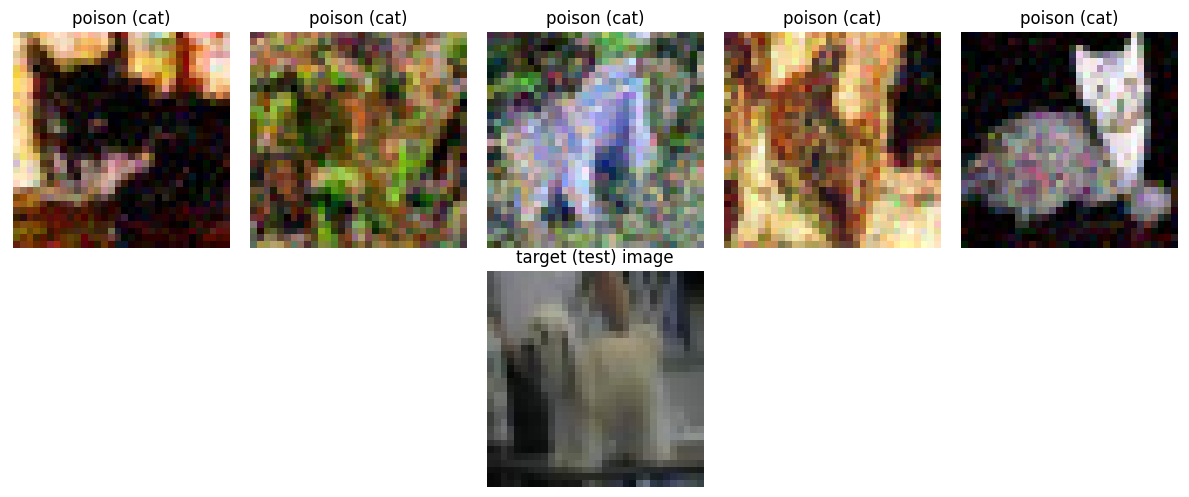

In [10]:
def denorm(img):
    """[-1,1] -> [0,1] for plotting"""
    return (img.clamp(-1, 1) + 1) / 2

def generate_poison_set(
    base_class_idx: int,
    target_class_idx: int,
    num_poisons: int = 25,
    t_start: int = 250,
):
    base_indices = get_indices_by_class(train_set, base_class_idx)
    target_indices = get_indices_by_class(test_set, target_class_idx)

    chosen_base = random.sample(base_indices, num_poisons)
    target_idx = random.choice(target_indices)
    target_img, _ = test_set[target_idx]
    target_img = target_img.unsqueeze(0)

    poisons = []
    for i, idx in enumerate(chosen_base):
        base_img, base_label = train_set[idx]
        base_img = base_img.unsqueeze(0)
        poison = make_poison(base_img, target_img, surrogate, t_start=t_start)
        poisons.append((idx, poison.cpu(), base_label))
        print(f"generated poison {i+1}/{num_poisons}")

    return poisons, target_img, target_idx


# Example: poison "cat" images to collide with a "dog" target image
poisons, target_img, target_idx = generate_poison_set(
    base_class_idx=CLASSES.index("cat"),
    target_class_idx=CLASSES.index("dog"),
    num_poisons=25,
    t_start=250,
)

# --- visualize a few ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(denorm(poisons[i][1][0]).permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"poison ({CLASSES[poisons[i][2]]})")
    axes[0, i].axis("off")
axes[1, 2].imshow(denorm(target_img[0]).permute(1, 2, 0).numpy())
axes[1, 2].set_title("target (test) image")
axes[1, 2].axis("off")
for i in [0, 1, 3, 4]:
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("poison_examples.png", dpi=150)
plt.show()


In [14]:
# class PoisonedCIFAR10(torch.utils.data.Dataset):
#     """Wraps CIFAR-10 train set, replacing/adding poison samples."""
#     def __init__(self, clean_dataset, poisons):
#         self.clean_dataset = clean_dataset
#         self.poisons = poisons  # list of (tensor[1,3,32,32], label)

#     def __len__(self):
#         return len(self.clean_dataset) + len(self.poisons)

#     def __getitem__(self, idx):
#         if idx < len(self.clean_dataset):
#             return self.clean_dataset[idx]
#         else:
#             img, label = self.poisons[idx - len(self.clean_dataset)]
#             return img.squeeze(0), label



In [11]:
class PoisonedCIFAR10(torch.utils.data.Dataset):
    """CIFAR-10 dataset with selected samples replaced by poison images."""

    def __init__(self, clean_dataset, poisons):
        self.clean_dataset = clean_dataset

        # Map original CIFAR-10 index -> poison
        self.poisons = {
            idx: (img, label)
            for idx, img, label in poisons
        }

    def __len__(self):
        return len(self.clean_dataset)

    def __getitem__(self, idx):
        if idx in self.poisons:
            img, label = self.poisons[idx]

            if img.dim() == 4:
                img = img.squeeze(0)

            return img, label

        return self.clean_dataset[idx]

In [12]:
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Projection shortcut when dimensions change
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        out = self.relu(out)

        return out


class TransferResNet(nn.Module):
    """Small ResNet-style CNN for CIFAR-10 transferability experiments."""
    
    def __init__(self, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, return_features=False):
        x = self.stem(x)

        x = self.layer1(x)   # 32x32
        x = self.layer2(x)   # 16x16
        x = self.layer3(x)   # 8x8

        feat = self.pool(x).flatten(1)  # 256-d feature vector
        out = self.classifier(feat)

        if return_features:
            return out, feat

        return out


In [15]:
def train_victim(dataset, epochs=8, batch_size=256):
    """Victim CNN — architecture can differ from surrogate to test transferability."""
    model = TransferResNet().to(device)  # swap for a different arch if you want to test transfer
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Victim] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model


poisoned_dataset = PoisonedCIFAR10(train_set, poisons)

print("Original dataset size:", len(train_set))
print("Poisoned dataset size:", len(poisoned_dataset))

Original dataset size: 50000
Poisoned dataset size: 50000


In [16]:
victim_clean = train_victim(train_set, epochs=8)      # baseline, no poisoning
victim_poisoned = train_victim(poisoned_dataset, epochs=8)  # with poisons injected

[Victim] epoch 1/8 loss=1.3544 acc=0.5043
[Victim] epoch 2/8 loss=0.8745 acc=0.6884
[Victim] epoch 3/8 loss=0.6682 acc=0.7649
[Victim] epoch 4/8 loss=0.5328 acc=0.8147
[Victim] epoch 5/8 loss=0.4376 acc=0.8481
[Victim] epoch 6/8 loss=0.3614 acc=0.8757
[Victim] epoch 7/8 loss=0.2969 acc=0.8968
[Victim] epoch 8/8 loss=0.2315 acc=0.9216
[Victim] epoch 1/8 loss=1.3198 acc=0.5187
[Victim] epoch 2/8 loss=0.8315 acc=0.7032
[Victim] epoch 3/8 loss=0.6241 acc=0.7797
[Victim] epoch 4/8 loss=0.4973 acc=0.8282
[Victim] epoch 5/8 loss=0.4115 acc=0.8572
[Victim] epoch 6/8 loss=0.3327 acc=0.8843
[Victim] epoch 7/8 loss=0.2727 acc=0.9060
[Victim] epoch 8/8 loss=0.2135 acc=0.9265


In [17]:
def evaluate_clean_accuracy(model, dataset, batch_size=512):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


def check_target_misclassified(model, target_img, target_true_label, base_class_idx):
    with torch.no_grad():
        out = model(target_img.to(device))
        pred = out.argmax(1).item()
    print(f"Target true label: {CLASSES[target_true_label]}")
    print(f"Predicted by clean-trained victim / poisoned victim: {CLASSES[pred]}")
    attack_success = (pred == base_class_idx)  # misclassified AS the poison's base class
    return attack_success, pred

def evaluate_target_class_asr(
    model,
    dataset,
    target_class_idx,
    base_class_idx,
    batch_size=512,
):
    """
    Targeted ASR:
    Among all samples belonging to target_class_idx,
    calculate the fraction classified as base_class_idx.
    """
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )

    total_targets = 0
    successful_attacks = 0

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Only evaluate images from the target class
            mask = (y == target_class_idx)

            if not mask.any():
                continue

            x_target = x[mask].to(device)

            out = model(x_target)
            pred = out.argmax(dim=1)

            successful_attacks += (pred == base_class_idx).sum().item()
            total_targets += x_target.size(0)

    asr = successful_attacks / total_targets if total_targets > 0 else 0.0

    return asr, successful_attacks, total_targets


target_true_label = test_set.targets[target_idx]
base_class_idx = CLASSES.index("cat")

print("\n=== CLEAN ACCURACY ===")
acc_clean_model = evaluate_clean_accuracy(victim_clean, test_set)
acc_poisoned_model = evaluate_clean_accuracy(victim_poisoned, test_set)
print(f"Clean-trained victim test accuracy:    {acc_clean_model:.4f}")
print(f"Poison-trained victim test accuracy:   {acc_poisoned_model:.4f}  (should stay close to clean — that's the 'clean-label' property)")

print("\n=== ATTACK SUCCESS (single target) ===")
success_before, pred_before = check_target_misclassified(victim_clean, target_img, target_true_label, base_class_idx)
success_after, pred_after = check_target_misclassified(victim_poisoned, target_img, target_true_label, base_class_idx)
print(f"Misclassified as '{CLASSES[base_class_idx]}' BEFORE poisoning: {success_before}")
print(f"Misclassified as '{CLASSES[base_class_idx]}' AFTER poisoning:  {success_after}")

print("\n=== TARGET-CLASS ATTACK SUCCESS RATE ===")

target_class_idx = CLASSES.index("dog")
base_class_idx = CLASSES.index("cat")

asr_clean, success_clean, total_targets = evaluate_target_class_asr(
    victim_clean,
    test_set,
    target_class_idx,
    base_class_idx,
)

asr_poisoned, success_poisoned, _ = evaluate_target_class_asr(
    victim_poisoned,
    test_set,
    target_class_idx,
    base_class_idx,
)

print(
    f"Clean model ASR:    "
    f"{success_clean}/{total_targets} = {asr_clean:.4f} "
    f"({asr_clean * 100:.2f}%)"
)

print(
    f"Poisoned model ASR: "
    f"{success_poisoned}/{total_targets} = {asr_poisoned:.4f} "
    f"({asr_poisoned * 100:.2f}%)"
)

print(
    f"ASR increase: "
    f"{(asr_poisoned - asr_clean):.4f} "
    f"({(asr_poisoned - asr_clean) * 100:.2f} percentage points)"
)


=== CLEAN ACCURACY ===
Clean-trained victim test accuracy:    0.8051
Poison-trained victim test accuracy:   0.7527  (should stay close to clean — that's the 'clean-label' property)

=== ATTACK SUCCESS (single target) ===
Target true label: dog
Predicted by clean-trained victim / poisoned victim: horse
Target true label: dog
Predicted by clean-trained victim / poisoned victim: deer
Misclassified as 'cat' BEFORE poisoning: False
Misclassified as 'cat' AFTER poisoning:  False

=== TARGET-CLASS ATTACK SUCCESS RATE ===
Clean model ASR:    75/1000 = 0.0750 (7.50%)
Poisoned model ASR: 161/1000 = 0.1610 (16.10%)
ASR increase: 0.0860 (8.60 percentage points)


In [18]:
# print("\n=== POISON CHECK ===")

# for i, (idx, poison_img, label) in enumerate(poisons):
#     print(
#         f"Poison {i}: "
#         f"train_idx={idx}, "
#         f"label={label} ({CLASSES[label]}), "
#         f"original_label={train_set[idx][1]} ({CLASSES[train_set[idx][1]]})"
#     )

In [19]:
from sklearn.metrics import confusion_matrix
import numpy as np

def get_confusion_matrix(model, dataset, num_classes=10, batch_size=512):
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            preds = out.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    return confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(num_classes))
    )

In [20]:
cm_clean = get_confusion_matrix(victim_clean, test_set)
cm_poisoned = get_confusion_matrix(victim_poisoned, test_set)

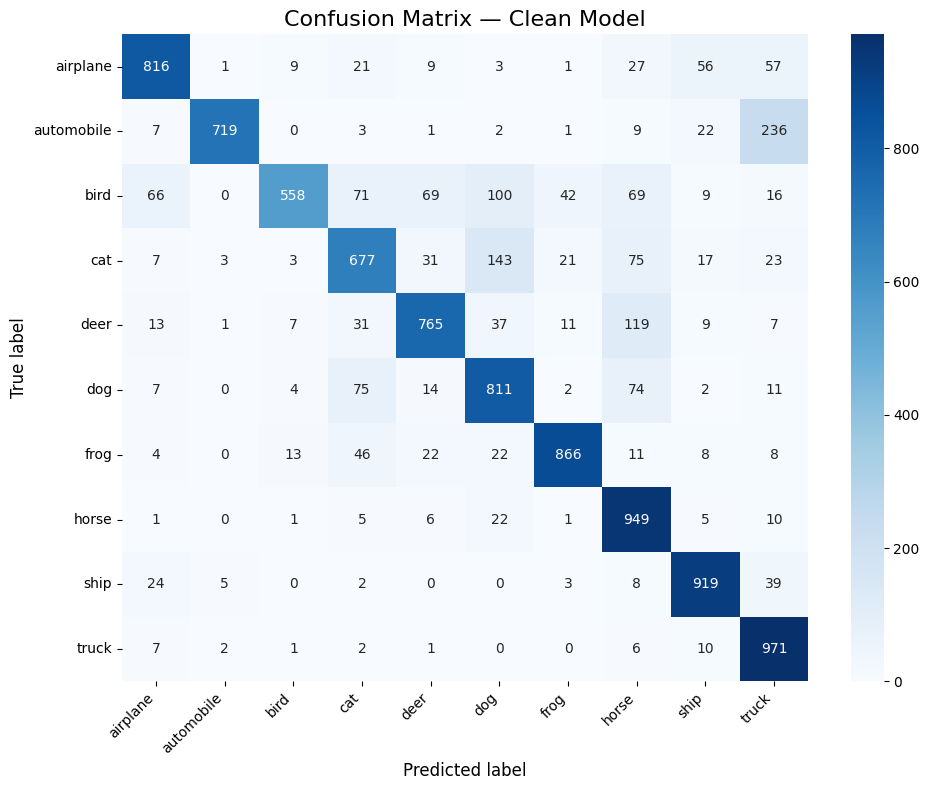

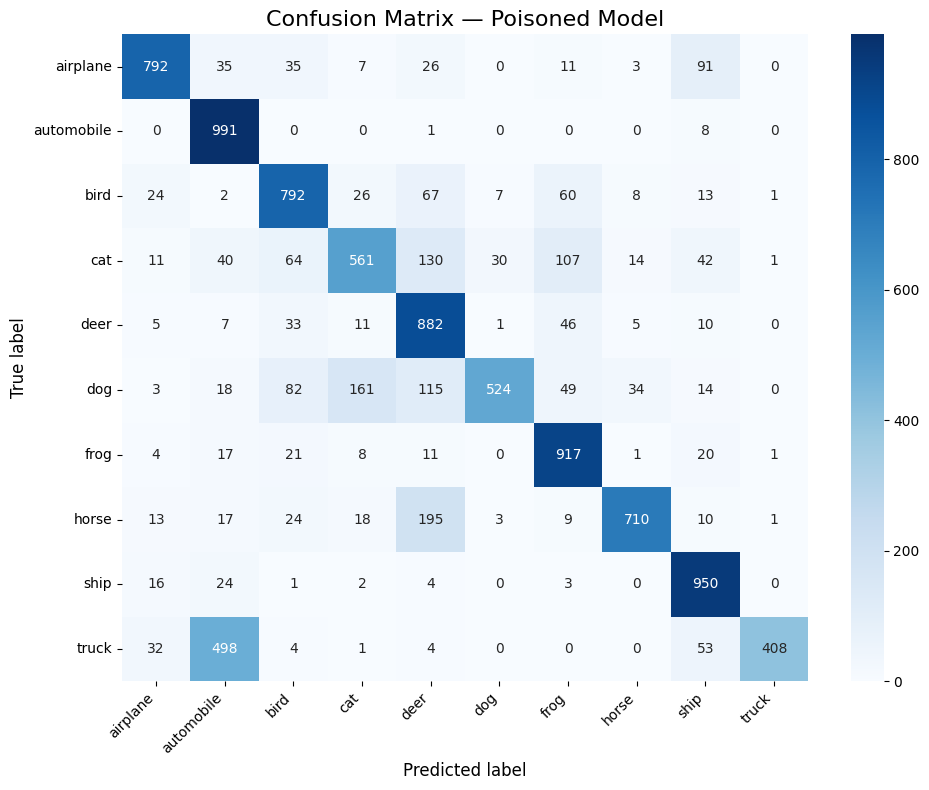

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = train_set.classes

def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# Clean model
plot_confusion_matrix(
    cm_clean,
    CLASSES,
    "Confusion Matrix — Clean Model"
)

# Poisoned model
plot_confusion_matrix(
    cm_poisoned,
    CLASSES,
    "Confusion Matrix — Poisoned Model"
)

In [14]:
def run_full_experiment(
    base_class_idx,
    target_class_idx,
    num_targets=20,
    num_poisons_per_target=25,
    t_start=250,
    victim_epochs=8,
):
    results = []
    for i in range(num_targets):
        poisons, target_img, target_idx = generate_poison_set(
            base_class_idx, target_class_idx, num_poisons_per_target, t_start
        )
        poisoned_dataset = PoisonedCIFAR10(train_set, poisons)
        victim = train_victim(poisoned_dataset, epochs=victim_epochs)
        target_true_label = test_set.targets[target_idx]
        success, pred = check_target_misclassified(victim, target_img, target_true_label, base_class_idx)
        results.append(success)
        print(f"[{i+1}/{num_targets}] success={success}")

    asr = sum(results) / len(results)
    print(f"\nFINAL ATTACK SUCCESS RATE: {asr:.2%}")
    return asr, results

# Uncomment to run the full experiment (slow — budget your Colab session time)
# asr, results = run_full_experiment(
#     base_class_idx=CLASSES.index("cat"),
#     target_class_idx=CLASSES.index("dog"),
#     num_targets=20,
#     num_poisons_per_target=25,
# )
